Loading the cleaned data To create visualizations and give insights on the best time to book flight tickets And give suitable recommendations. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/flight_pricing_cleaned.csv")
print("Shape:", df.shape)
df.head()

Shape: (98039, 18)


,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Total_Stops,Distance_km,Travel_Class,Days_Before_Departure,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price,Duration_Minutes
0,FL133547,Indigo,Hyderabad,Ahmedabad,2025-08-02,8:10 PM,21:50,0.0,910.5,Economy,43.0,Monsoon,Saturday,Boeing 737,Mobile App,5.0,5181.56,100.2
1,FL133458,AirAsia India,Pune,Mumbai,2025-06-05,12:10,12:55,0.0,150.0,Economy,45.0,Monsoon,Thursday,ATR 72,Website,3.0,2000.00,45.0
2,FL173851,Qatar Airways,Sydney,Pune,2025-02-11,5:05 PM,7:53 AM,1.0,10168.1,Economy,3.0,NaN,Tuesday,Boeing 777,Mobile App,3.0,174762.69,888.0
3,FL101953,AirAsia India,Bangalore,Mumbai,2025-04-19,07:05,10:16 AM,1.0,868.3,Economy,33.0,Summer,Saturday,Airbus A320,Mobile App,1.0,2846.09,191.0
4,FL162887,British Airways,Sydney,Goa,2026-07-05,10:40 PM,12:36,0.0,10478.0,Economy,6.0,Monsoon,Sunday,Airbus A320,Website,2.0,145331.64,835.8


Price distribution is important as it helps us understand how much flights usually cost and whether they are very cheap or very expensive tickets, and it is a very important category for visualizing. 

Visualization 1 :

Histogram is used to show how ticket flight prices are spread. We also add a KDE line, which makes the overall shape easier to understand for us. 

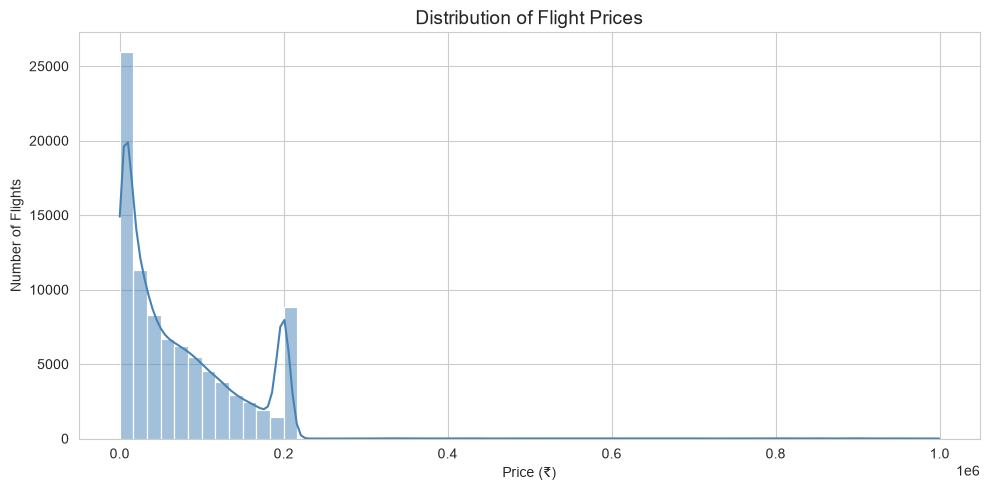

Skewness: 3.1
Median price: ₹49,159
Mean price:   ₹73,026


In [2]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=60, kde=True, color='steelblue')
plt.title('Distribution of Flight Prices', fontsize=14)
plt.xlabel('Price (₹)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

print("Skewness:", df['Price'].skew().round(2))
print("Median price: ₹{:,.0f}".format(df['Price'].median()))
print("Mean price:   ₹{:,.0f}".format(df['Price'].mean()))

**Insight:**
- The distribution is right-skewed (long tail toward high prices) — a positive skewness
  value confirms this, and the fact that mean > median is the classic signature of a
  right-skewed distribution.
- This means: most flights are moderately priced, but a smaller number of expensive
  flights (long-haul, business/first class) pull the average up. **The median is a more
  representative "typical price" than the mean** for this dataset — worth stating
  explicitly, since it changes how you'd summarize "average" price to someone.

Visualization 2:

Another fact is that many airlines have higher prices compared to others, so this is also another important category in the analysis. 

C:\Users\DELL\AppData\Local\Temp\ipykernel_23116\1418878600.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Airline', y='Price', order=order, palette='viridis')


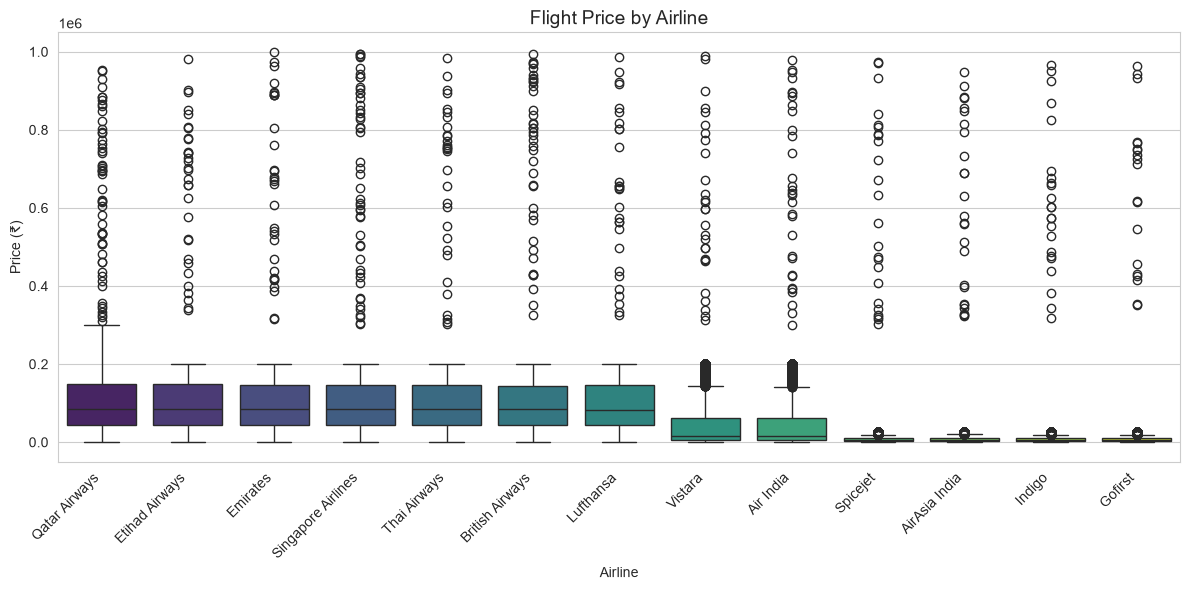

Airline
Qatar Airways         86060.265
Etihad Airways        85175.985
Emirates              85115.960
Singapore Airlines    84814.605
Thai Airways          84802.265
British Airways       84100.920
Lufthansa             83152.245
Vistara               16949.640
Air India             16470.875
Spicejet               6224.660
AirAsia India          6164.165
Indigo                 6073.590
Gofirst                5959.905
Name: Price, dtype: float64


In [4]:
plt.figure(figsize=(12, 6))
# Order airlines by median price so the chart reads high-to-low, left-to-right
order = df.groupby('Airline')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Airline', y='Price', order=order, palette='viridis')
plt.title('Flight Price by Airline', fontsize=14)
plt.xlabel('Airline')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(df.groupby('Airline')['Price'].median().sort_values(ascending=False))

**Insight:**
- There's a clear split between international full-service carriers (e.g. Emirates,
  Qatar Airways, Singapore Airlines) at the high end and Indian domestic/budget
  carriers (Indigo, SpiceJet, AirAsia India, GoFirst) at the low end — this likely
  reflects route length as much as airline pricing strategy (international routes are
  simply longer and cost more regardless of carrier).
- Within-airline spread is large for every airline — meaning **airline alone is a weak
  predictor of price**; route and class likely matter more (we check this next).

Visualisation 3:

Another important factor influencing the price Price is based on the number of stops in a travel. 


C:\Users\DELL\AppData\Local\Temp\ipykernel_23116\2405665368.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Total_Stops', y='Price', palette='coolwarm')


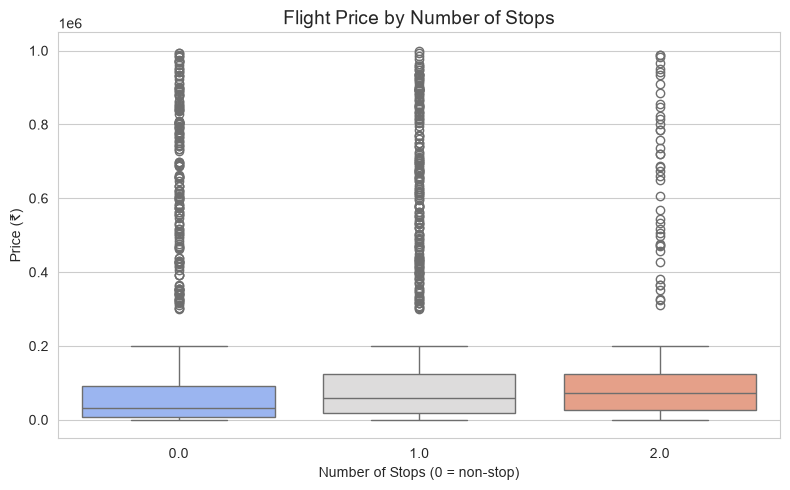

                median          mean  count
Total_Stops                                
0.0          32250.895  61609.096989  34574
1.0          60327.620  79510.286335  40073
2.0          71215.500  84681.120740  11184


In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Total_Stops', y='Price', palette='coolwarm')
plt.title('Flight Price by Number of Stops', fontsize=14)
plt.xlabel('Number of Stops (0 = non-stop)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

print(df.groupby('Total_Stops')['Price'].agg(['median', 'mean', 'count']))

**Insight:**
- Price rises with number of stops rather than falling — the opposite of the common
  assumption that connections are always cheaper.
- The likely explanation: in this dataset, longer/international routes are more likely
  to require a layover, so `Total_Stops` is probably acting as a proxy for route
  distance 

Visualisation 4:

The next set of analysis is based on price versus days before departure. This is an important analysis, and prices vary because of the days before departure. And to find the extent of this, we use this code below. 

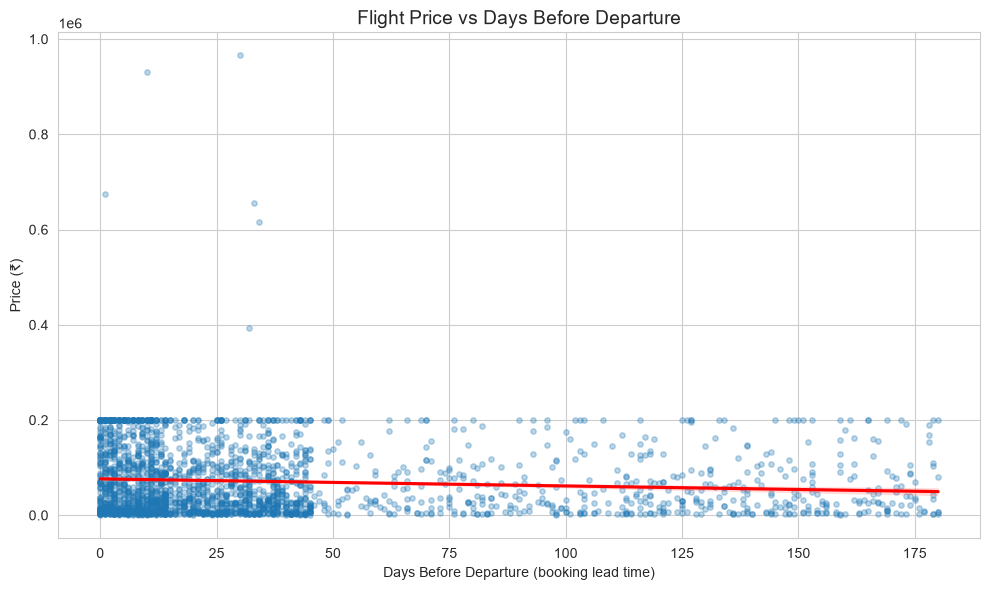

Booking_Window
0-7       67568.565
8-15      52405.940
16-30     43571.930
31-60     39133.925
61-100    39626.830
100+      39096.830
Name: Price, dtype: float64


In [6]:
# Subsample for a readable scatter plot - 3000 points is enough to see the pattern
# without the plot becoming an unreadable solid mass of overlapping dots
sample = df.sample(3000, random_state=1)

plt.figure(figsize=(10, 6))
sns.regplot(data=sample, x='Days_Before_Departure', y='Price',
            scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'})
plt.title('Flight Price vs Days Before Departure', fontsize=14)
plt.xlabel('Days Before Departure (booking lead time)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

# Bin into ranges to see the trend as a table, not just a scatter
bins = [0, 7, 15, 30, 60, 100, 200]
labels = ['0-7', '8-15', '16-30', '31-60', '61-100', '100+']
df['Booking_Window'] = pd.cut(df['Days_Before_Departure'], bins=bins, labels=labels)
print(df.groupby('Booking_Window', observed=True)['Price'].median())

**Insight:**
- The trend line is close to flat with a very slight negative slope — booking earlier
  correlates with marginally lower prices, but the effect is much weaker than commonly
  assumed. The binned median table shows the picture more clearly than the noisy scatter.
- **Takeaway for travelers:** in this dataset, "book early to save money" holds only
  weakly — route, class, and airline appear to matter far more than lead time. This is
  a genuinely useful, slightly counter-intuitive finding worth highlighting.

Visualization 5:

From the above analysis, we come to know that flight ticket prices are influenced by many factors, but we have to find out the co-relation and which factor affects the flight ticket prices more. We are creating a co-relation map for that. 

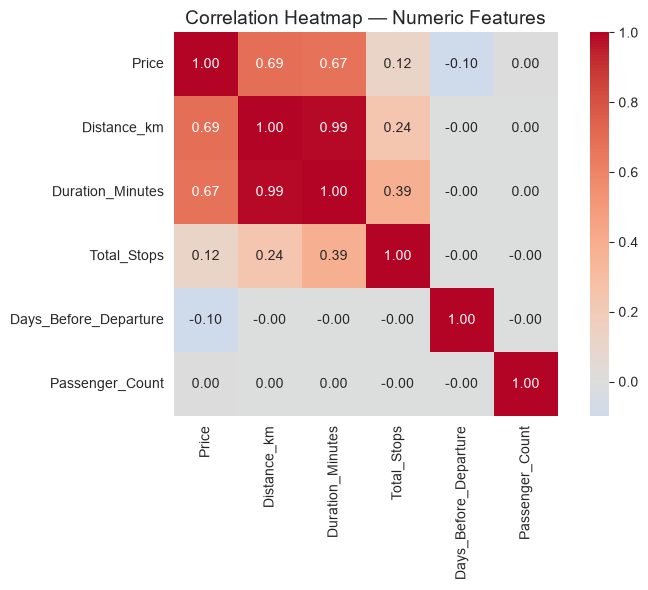

Price                    1.000000
Distance_km              0.686878
Duration_Minutes         0.669600
Total_Stops              0.116279
Passenger_Count          0.003862
Days_Before_Departure   -0.099375
Name: Price, dtype: float64


In [7]:
numeric_cols = ['Price', 'Distance_km', 'Duration_Minutes', 'Total_Stops',
                'Days_Before_Departure', 'Passenger_Count']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

print(corr['Price'].sort_values(ascending=False))

**Insight:**
- Distance in kilometers and Duration_Minutes` are by far the strongest correlates of price
  (both make intuitive sense: longer flights cost more) — and they're strongly
  correlated with *each other* too, which explains why Total_Stops showed the same
  directional pattern as distance in Visualization 3 (longer routes need more stops).
- Days_Before_Departure and Passenger_Count` show weak correlation with price,
  confirming the flat trend seen in Visualization 4.

  that doesn't rule out other underlying drivers (e.g. international vs domestic route
  type) that influence both.

 Price by Travel Class

Not required for the 5-chart minimum, but class is one of the clearest, most
interpretable price drivers in the dataset, so it's worth including.

C:\Users\DELL\AppData\Local\Temp\ipykernel_23116\3550344837.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Travel_Class', y='Price', order=class_order, palette='mako')


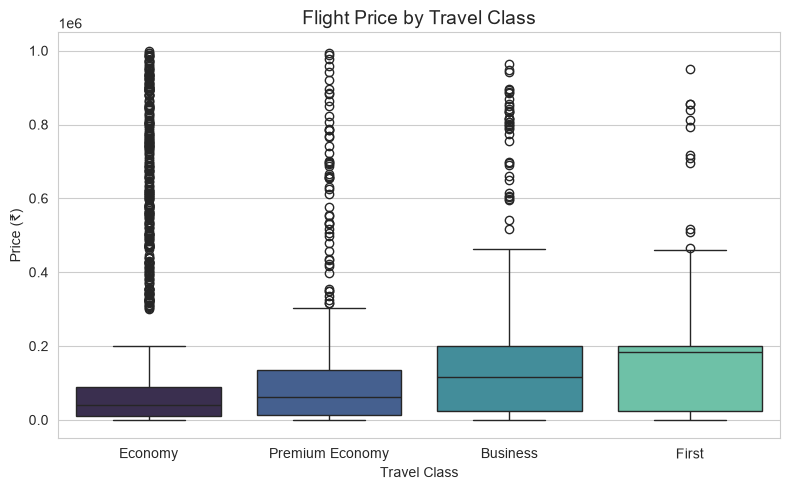

Travel_Class
Economy             39824.330
Premium Economy     61339.040
Business           116471.230
First              184200.855
Name: Price, dtype: float64


In [8]:
plt.figure(figsize=(8, 5))
class_order = df.groupby('Travel_Class')['Price'].median().sort_values().index
sns.boxplot(data=df, x='Travel_Class', y='Price', order=class_order, palette='mako')
plt.title('Flight Price by Travel Class', fontsize=14)
plt.xlabel('Travel Class')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

print(df.groupby('Travel_Class')['Price'].median().sort_values())

**Insight:**
- Travel class shows the cleanest, largest, most consistent price gap of any factor
  examined — Business and First class are several multiples of Economy, with little
  overlap between classes. This is the single most reliable price predictor in the
  dataset.